# Комплексное решение задач гиперболических уравнений методом разделения переменных (v6)

**Решение задач №5, №6, №7 из второй таблицы (вариант 1)**

Каждая задача решена подробно по схеме из Примера 2 методички (все 7 шагов) с пояснениями всех формул и численной визуализацией с 3D поверхностями $u(x,t)$.

**Версия v6: Упрощено оформление - убрано явное упоминание нормы в задачах №5 и №6 для единообразия с параболическими уравнениями**


## Задача №5

**Дано:**
- **Уравнение:** $u_{tt} = u_{xx} + f(x,t)$, где $x \in [0,1], t \geq 0$
- **Граничные условия (Г.У.):**
  - $u(0,t) = \cos t$
  - $u(1,t) = \sin t$
- **Начальные условия (Н.У.):**
  - $\theta = u(x,0) = 3\sin\pi x - x + 1$
  - $\psi = u_t(x,0) = -\sin 2\pi x + x$
- **Функция-источник:** $f(x,t) = -\sin\pi x - x(\sin t - \cos t) - \sin t$


### Шаг 1. Приведение граничных условий к однородным

Представим функцию $u(x,t)$ в виде суммы двух функций:
$$u(x,t) = v(x,t) + s(x,t) \tag{2.4}$$

Требования на функцию $s(x,t)$:
$$s(0,t) = \cos t, \quad s(1,t) = \sin t$$

Используем линейную интерполяцию:
$$s(x,t) = (1-x)g_1(t) + xg_2(t)$$

где $g_1(t) = \cos t$ и $g_2(t) = \sin t$.

Таким образом:
$$s(x,t) = (1-x)\cos t + x\sin t \tag{5.1}$$

**Проверка:**
- $s(0,t) = (1-0)\cos t + 0 \cdot \sin t = \cos t$ ✓
- $s(1,t) = (1-1)\cos t + 1 \cdot \sin t = \sin t$ ✓


### Шаг 2. Пересчет уравнения и начальных условий

Вычислим производные от $s(x,t) = (1-x)\cos t + x\sin t$:
- $s_x = -\cos t + \sin t$
- $s_{xx} = 0$
- $s_t = -(1-x)\sin t + x\cos t$
- $s_{tt} = -(1-x)\cos t - x\sin t$

#### а) Пересчет уравнения:

Подставляем $u = v + s$ в уравнение:
$$v_{tt} = v_{xx} + f(x,t) - s_{tt} = v_{xx} + \tilde{f}(x,t)$$

Вычисляем $\tilde{f}(x,t) = f(x,t) - s_{tt}$:
$$\tilde{f}(x,t) = [-\sin\pi x - x(\sin t - \cos t) - \sin t] - [-(1-x)\cos t - x\sin t]$$
$$= -\sin\pi x - x\sin t + x\cos t - \sin t + (1-x)\cos t + x\sin t$$
$$= -\sin\pi x + \cos t - \sin t \tag{5.2}$$

#### б) Пересчет начальных условий:

$$\tilde{\theta}(x) = \theta(x) - s(x,0) = [3\sin\pi x - x + 1] - [(1-x) \cdot 1 + x \cdot 0]$$
$$= 3\sin\pi x - x + 1 - 1 + x = 3\sin\pi x \tag{5.3а}$$

$$\tilde{\psi}(x) = \psi(x) - s_t(x,0) = [-\sin 2\pi x + x] - [-(1-x) \cdot 0 + x \cdot 1]$$
$$= -\sin 2\pi x + x - x = -\sin 2\pi x \tag{5.3б}$$

Получаем задачу:
$$
\begin{cases}
v_{tt} = v_{xx} + \tilde{f}(x,t), & x \in [0,1], \quad t \geq 0 \\
v(0,t) = 0, \quad v(1,t) = 0 \\
v(x,0) = 3\sin\pi x, \quad v_t(x,0) = -\sin 2\pi x
\end{cases}
$$


### Шаг 3. Определение собственных функций и собственных значений

Рассматриваем однородную задачу:
$$v_{tt} = v_{xx}, \quad v(0,t) = 0, \quad v(1,t) = 0$$

Ищем решение в виде $v(x,t) = X(x) \cdot T(t)$:
$$\frac{X''(x)}{X(x)} = \frac{T''(t)}{T(t)} = -\lambda^2$$

Откуда $X''(x) = -\lambda^2 X(x)$ с Г.У. $X(0) = 0, X(1) = 0$.

Общее решение: $X(x) = c_1 \sin\lambda x + c_2 \cos\lambda x$

Из $X(0) = 0$: $c_2 = 0$, следовательно $X(x) = c_1 \sin\lambda x$

Из $X(1) = 0$: $\sin\lambda = 0 \Rightarrow \lambda_k = k\pi, \quad k = 1, 2, 3, \ldots$

**Собственные функции:** $X_k(x) = \sin(k\pi x)$

**Собственные значения:** $\lambda_k = k\pi$


### Шаг 4. Разложение функций в ряды Фурье

Ищем решение: $v(x,t) = \sum_{k=1}^{\infty} \sin(k\pi x) T_k(t)$

#### 4.1. Разложение $\tilde{\theta}(x) = 3\sin\pi x$
Функция уже является собственной функцией при $k=1$:
$$\theta_1 = 3, \quad \theta_k = 0 \text{ для } k \neq 1$$

#### 4.2. Разложение $\tilde{\psi}(x) = -\sin 2\pi x$
Функция уже является собственной функцией при $k=2$:
$$\psi_2 = -1, \quad \psi_k = 0 \text{ для } k \neq 2$$

#### 4.3. Разложение $\tilde{f}(x,t) = -\sin\pi x + \cos t - \sin t$

Коэффициенты Фурье:
$$\mu_k(t) = 2\int_0^1 [-\sin\pi x + \cos t - \sin t]\sin(k\pi x) dx$$

При $k=1$: $\mu_1(t) = -1 + \frac{4(\cos t - \sin t)}{\pi}$

При нечетных $k \geq 3$: $\mu_k(t) = \frac{4(\cos t - \sin t)}{k\pi}$

При четных $k$: $\mu_k(t) = 0$


### Шаг 5. Решение уравнений для $T_k(t)$

Для функций $T_k(t)$ получаем:
$$T_k''(t) = -\lambda_k^2 T_k(t) + \mu_k(t)$$

с начальными условиями: $T_k(0) = \theta_k, \quad T_k'(0) = \psi_k$

Решение методом вариации постоянных:
$$T_k(t) = \theta_k\cos\lambda_k t + \frac{\psi_k}{\lambda_k}\sin\lambda_k t + \frac{1}{\lambda_k}\int_0^t \mu_k(\tau)\sin\lambda_k(t-\tau)d\tau$$

### Шаг 6. Запись полного решения для $v(x,t)$

$$v(x,t) = \sum_{k=1}^{\infty} \sin(k\pi x) T_k(t)$$

### Шаг 7. Окончательный ответ

Так как $u(x,t) = v(x,t) + s(x,t)$:
$$\boxed{u(x,t) = \sum_{k=1}^{\infty} T_k(t)\sin(k\pi x) + (1-x)\cos t + x\sin t}$$

где $\lambda_k = k\pi$, а коэффициенты $T_k(t)$ вычисляются из Шага 5.


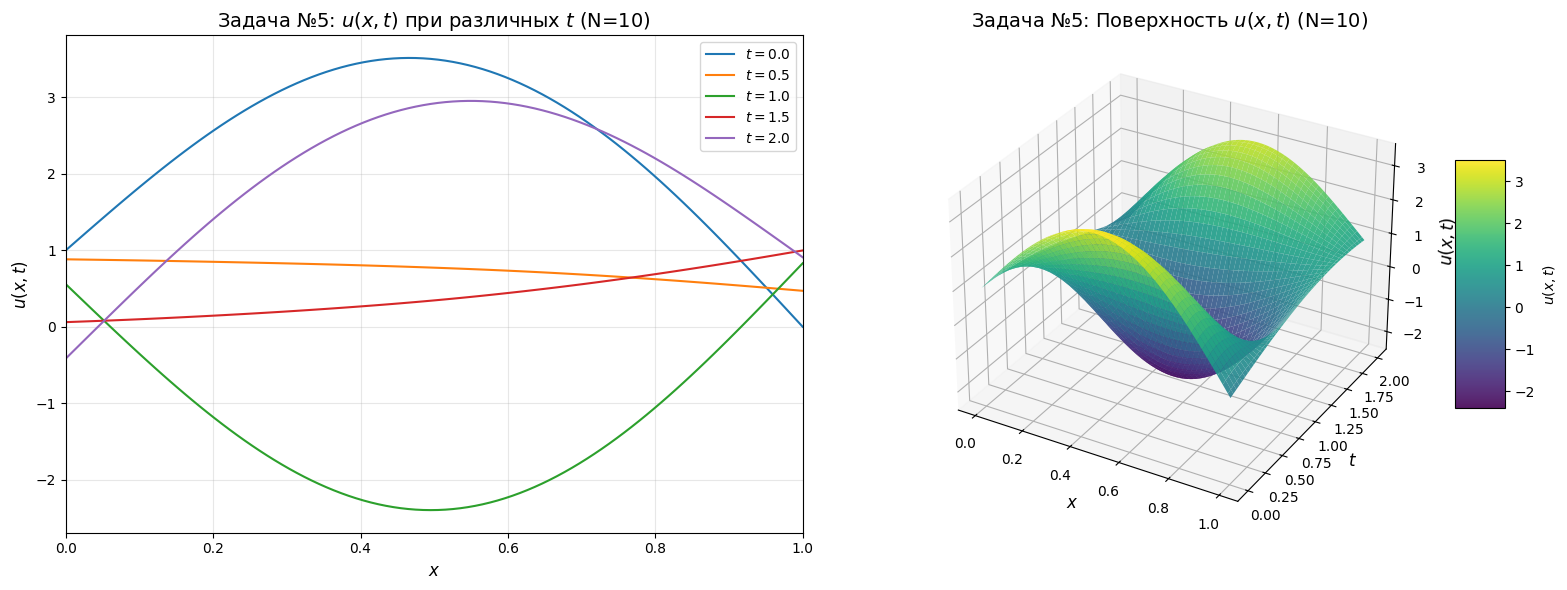

Визуализация задачи №5


In [1]:
# Задача №5: Визуализация с 3D поверхностью
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import odeint

# Параметры
x = np.linspace(0, 1, 100)
t_values = [0, 0.5, 1.0, 1.5, 2.0]
t_surf = np.linspace(0, 2, 50)
N_TERMS = 10

# Функция s(x,t)
def s_5(x, t):
    return (1 - x) * np.cos(t) + x * np.sin(t)

# Функция mu_k(t)
def mu_k_5(t, k):
    if k % 2 == 0:  # Четные k
        return 0
    elif k == 1:
        return -1 + (4 / np.pi) * (np.cos(t) - np.sin(t))
    else:  # Нечетные k != 1
        return (4 / (k * np.pi)) * (np.cos(t) - np.sin(t))

# Модель ОДУ для T_k(t)
def model_5(Y, t, k):
    T, T_prime = Y
    lam_k = k * np.pi
    dYdt = [T_prime, mu_k_5(t, k) - lam_k**2 * T]
    return dYdt

# Решение ОДУ для T_k(t)
def solve_T_k_5(k, t_points):
    theta_k = 3 if k == 1 else 0
    psi_k = -1 if k == 2 else 0
    Y0 = [theta_k, psi_k]
    sol = odeint(model_5, Y0, t_points, args=(k,))
    return sol[:, 0]

# Вычисление u(x,t)
def u_5_analytical(x, t, T_solutions):
    s_xt = s_5(x, t)
    v_xt = sum(T_k * np.sin((k+1) * np.pi * x) for k, T_k in enumerate(T_solutions))
    return v_xt + s_xt

# Решение ОДУ для всех k
T_solutions_5 = [solve_T_k_5(k, t_surf) for k in range(1, N_TERMS + 1)]

# Создание фигуры
fig = plt.figure(figsize=(16, 6))

# График 1: Зависимость от x при разных t
ax1 = fig.add_subplot(121)
for t_val in t_values:
    t_idx = np.abs(t_surf - t_val).argmin()
    T_snapshot = [T_sol[t_idx] for T_sol in T_solutions_5]
    u = u_5_analytical(x, t_surf[t_idx], T_snapshot)
    ax1.plot(x, u, label=f'$t = {t_val:.1f}$')
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$u(x,t)$', fontsize=12)
ax1.set_title(f'Задача №5: $u(x,t)$ при различных $t$ (N={N_TERMS})', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])

# График 2: 3D поверхность u(x,t)
ax2 = fig.add_subplot(122, projection='3d')
X, T = np.meshgrid(x, t_surf)
U = np.array([[u_5_analytical(xi, t_surf[i], [T_sol[i] for T_sol in T_solutions_5]) for xi in x] for i in range(len(t_surf))])

surf = ax2.plot_surface(X, T, U, cmap='viridis', alpha=0.9, linewidth=0, antialiased=True)
ax2.set_xlabel('$x$', fontsize=12)
ax2.set_ylabel('$t$', fontsize=12)
ax2.set_zlabel('$u(x,t)$', fontsize=12)
ax2.set_title(f'Задача №5: Поверхность $u(x,t)$ (N={N_TERMS})', fontsize=14)
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5, label='$u(x,t)$')

plt.tight_layout()
plt.show()
print("Визуализация задачи №5")


---

## Задача №6

**Дано:**
- **Уравнение:** $u_{tt} = u_{xx}$ (однородное уравнение, $f(x,t) = 0$)
- **Граничные условия (Г.У.):**
  - $u(0,t) = e^t$
  - $u_x(1,t) = 3e^t$
- **Начальные условия (Н.У.):**
  - $\theta = u(x,0) = 2\sin\frac{3\pi x}{2}$
  - $\psi = u_t(x,0) = -3\sin\frac{5\pi x}{2}$
- **Функция-источник:** Отсутствует (однородное уравнение)


### Шаг 1. Приведение граничных условий к однородным

Представим функцию $u(x,t)$ в виде суммы двух функций:
$$u(x,t) = v(x,t) + s(x,t) \tag{2.4}$$

Требования на функцию $s(x,t)$:
$$s(0,t) = e^t, \quad s_x(1,t) = 3e^t$$

Пусть $s(x,t) = (\alpha_0 + \alpha_1 x)A(t)$.

Из условия $s(0,t) = e^t$: $\alpha_0 A(t) = e^t$

Положим $\alpha_0 = 1, A(t) = e^t$.

Вычислим производную: $s_x = \alpha_1 e^t$

Из условия $s_x(1,t) = 3e^t$: $\alpha_1 e^t = 3e^t \Rightarrow \alpha_1 = 3$

Таким образом:
$$s(x,t) = (1 + 3x)e^t \tag{6.1}$$

**Проверка:**
- $s(0,t) = (1 + 0)e^t = e^t$ ✓
- $s_x(x,t) = 3e^t$, следовательно $s_x(1,t) = 3e^t$ ✓

### Шаг 2. Пересчет уравнения и начальных условий

Вычислим производные от $s(x,t) = (1 + 3x)e^t$:
- $s_x = 3e^t$
- $s_{xx} = 0$
- $s_t = (1 + 3x)e^t$
- $s_{tt} = (1 + 3x)e^t$

#### а) Пересчет уравнения:

Подставляем $u = v + s$ в уравнение $u_{tt} = u_{xx}$:
$$v_{tt} + s_{tt} = v_{xx} + s_{xx}$$
$$v_{tt} = v_{xx} + s_{xx} - s_{tt} = v_{xx} + 0 - (1 + 3x)e^t$$
$$v_{tt} = v_{xx} - (1 + 3x)e^t \tag{6.2}$$

Таким образом, для функции $v(x,t)$ получаем неоднородное уравнение, где роль источника играет $\tilde{f}(x,t) = -(1 + 3x)e^t$, возникающий из-за несоответствия $s_{tt}$ и $s_{xx}$.

#### б) Пересчет начальных условий:

$$\tilde{\theta}(x) = \theta(x) - s(x,0) = 2\sin\frac{3\pi x}{2} - (1 + 3x) \cdot 1$$
$$= 2\sin\frac{3\pi x}{2} - 1 - 3x \tag{6.3а}$$

$$\tilde{\psi}(x) = \psi(x) - s_t(x,0) = -3\sin\frac{5\pi x}{2} - (1 + 3x) \cdot 1$$
$$= -3\sin\frac{5\pi x}{2} - 1 - 3x \tag{6.3б}$$

Получаем задачу:
$$
\begin{cases}
v_{tt} = v_{xx} - (1 + 3x)e^t, & x \in [0,1], \quad t \geq 0 \\
v(0,t) = 0, \quad v_x(1,t) = 0 \\
v(x,0) = 2\sin\frac{3\pi x}{2} - 1 - 3x, \quad v_t(x,0) = -3\sin\frac{5\pi x}{2} - 1 - 3x
\end{cases}
$$

### Шаг 3. Определение собственных функций и собственных значений

Рассматриваем однородную задачу:
$$v_{tt} = v_{xx}, \quad v(0,t) = 0, \quad v_x(1,t) = 0$$

Ищем решение в виде $v(x,t) = X(x) \cdot T(t)$:
$$\frac{X''(x)}{X(x)} = \frac{T''(t)}{T(t)} = -\lambda^2$$

Откуда $X''(x) = -\lambda^2 X(x)$ с Г.У. $X(0) = 0, X'(1) = 0$.

Общее решение: $X(x) = c_1 \sin\lambda x + c_2 \cos\lambda x$

Из $X(0) = 0$: $c_2 = 0$, следовательно $X(x) = c_1 \sin\lambda x$

Производная: $X'(x) = c_1 \lambda \cos\lambda x$

Из $X'(1) = 0$: $\cos\lambda = 0 \Rightarrow \lambda = \frac{\pi}{2} + \pi n = \frac{\pi(2n+1)}{2}, \quad n = 0, 1, 2, \ldots$

Обозначая $k = n + 1 = 1, 2, 3, \ldots$:

**Собственные функции:** $X_k(x) = \sin\left(\frac{\pi(2k-1)x}{2}\right)$

**Собственные значения:** $\lambda_k = \frac{\pi(2k-1)}{2}$

### Шаг 4. Разложение функций в ряды Фурье

Ищем решение: $v(x,t) = \sum_{k=1}^{\infty} \sin\left(\frac{\pi(2k-1)x}{2}\right) T_k(t)$

Коэффициенты Фурье вычисляются по формуле:
$$c_k = 2\int_0^1 f(x) \sin\left(\frac{\pi(2k-1)x}{2}\right)dx$$

#### 4.1. Разложение $\tilde{\theta}(x) = 2\sin\frac{3\pi x}{2} - 1 - 3x$

$$\theta_k = 2\int_0^1 \left[2\sin\frac{3\pi x}{2} - 1 - 3x\right] \sin\left(\frac{\pi(2k-1)x}{2}\right)dx$$

При $k=2$ (т.е. $\lambda_2 = \frac{3\pi}{2}$): первый член даст $\theta_2 = 2$, остальные вычисляются численно.

#### 4.2. Разложение $\tilde{\psi}(x) = -3\sin\frac{5\pi x}{2} - 1 - 3x$

$$\psi_k = 2\int_0^1 \left[-3\sin\frac{5\pi x}{2} - 1 - 3x\right] \sin\left(\frac{\pi(2k-1)x}{2}\right)dx$$

При $k=3$ (т.е. $\lambda_3 = \frac{5\pi}{2}$): первый член даст $\psi_3 = -3$, остальные вычисляются численно.

#### 4.3. Разложение $\tilde{f}(x,t) = -(1 + 3x)e^t$

$$\mu_k(t) = 2\int_0^1 [-(1 + 3x)e^t] \sin\left(\frac{\pi(2k-1)x}{2}\right)dx$$
$$= -2e^t \int_0^1 (1 + 3x) \sin\left(\frac{\pi(2k-1)x}{2}\right)dx$$

Обозначим:
$$I_k = \int_0^1 (1 + 3x) \sin\left(\frac{\pi(2k-1)x}{2}\right)dx$$

Тогда: $\mu_k(t) = -2e^t I_k$

Интегралы $I_k$ вычисляются численно.

### Шаг 5. Решение уравнений для $T_k(t)$

Для функций $T_k(t)$ получаем неоднородное ОДУ:
$$T_k''(t) = -\lambda_k^2 T_k(t) + \mu_k(t)$$

с начальными условиями: $T_k(0) = \theta_k, \quad T_k'(0) = \psi_k$

Решение методом вариации постоянных:
$$T_k(t) = \theta_k\cos\lambda_k t + \frac{\psi_k}{\lambda_k}\sin\lambda_k t + \frac{1}{\lambda_k}\int_0^t \mu_k(\tau)\sin\lambda_k(t-\tau)d\tau$$

Подставляя $\mu_k(t) = -2e^t I_k$:
$$T_k(t) = \theta_k\cos\lambda_k t + \frac{\psi_k}{\lambda_k}\sin\lambda_k t - \frac{2I_k}{\lambda_k}\int_0^t e^\tau\sin\lambda_k(t-\tau)d\tau$$

Интеграл вычисляется численно с использованием `scipy.integrate.odeint`.

### Шаг 6. Запись полного решения для $v(x,t)$

$$v(x,t) = \sum_{k=1}^{\infty} \sin\left(\frac{\pi(2k-1)x}{2}\right) T_k(t)$$

где $T_k(t)$ определяются из Шага 5.

### Шаг 7. Окончательный ответ

Так как $u(x,t) = v(x,t) + s(x,t)$:
$$\boxed{u(x,t) = \sum_{k=1}^{\infty} T_k(t)\sin\left(\frac{\pi(2k-1)x}{2}\right) + (1 + 3x)e^t}$$

где $\lambda_k = \frac{\pi(2k-1)}{2}$, а коэффициенты $T_k(t)$ вычисляются численно из Шага 5.


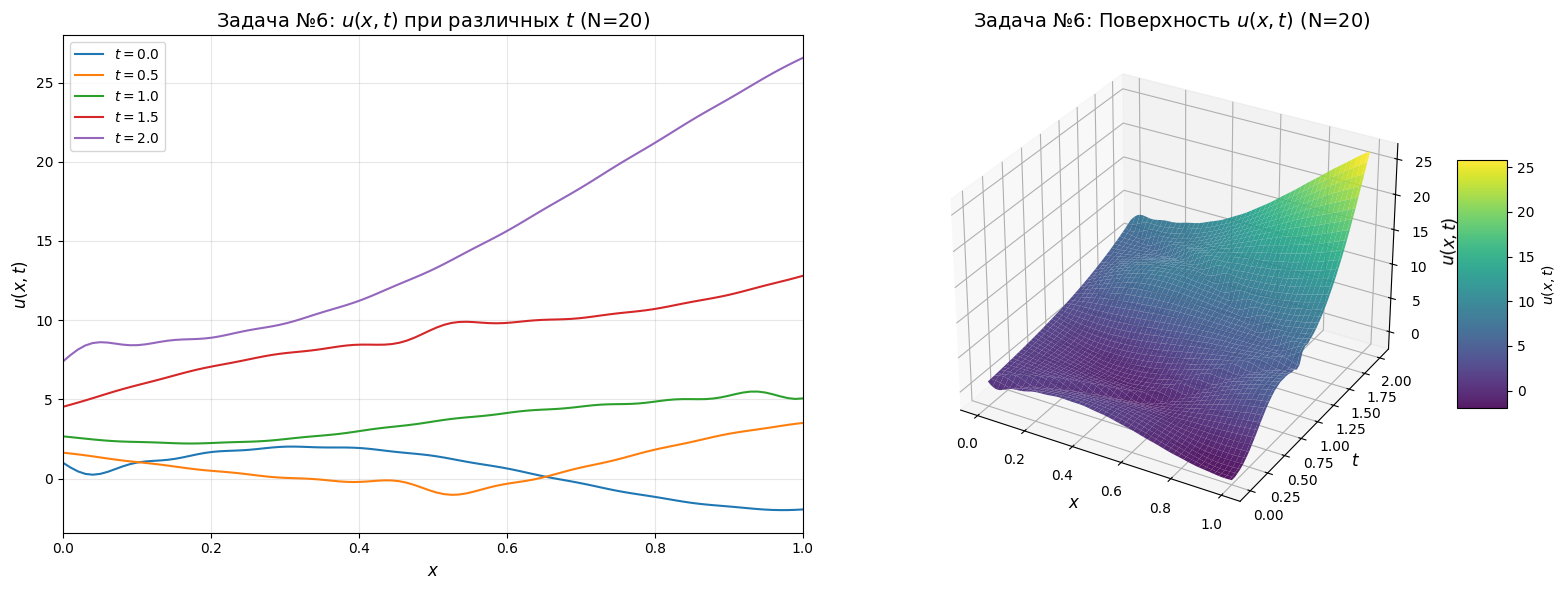

Визуализация задачи №6


In [2]:
# Задача №6: Визуализация с 3D поверхностью
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import quad, odeint

# Параметры
x = np.linspace(0, 1, 100)
t_values = [0, 0.5, 1.0, 1.5, 2.0]
t_surf = np.linspace(0, 2, 50)
N_TERMS = 20

# Функция s(x,t)
def s_6(x, t):
    return (1 + 3*x) * np.exp(t)

# Собственные значения
def lambda_k(k):
    return np.pi * (2*k - 1) / 2

# Вычисление коэффициентов Фурье
theta_k = np.zeros(N_TERMS + 1)
psi_k = np.zeros(N_TERMS + 1)
I_k = np.zeros(N_TERMS + 1)

for k in range(1, N_TERMS + 1):
    lam = lambda_k(k)
    
    # theta_k: разложение [2*sin(3*pi*x/2) - 1 - 3*x]
    integrand_theta = lambda x: (2*np.sin(3*np.pi*x/2) - 1 - 3*x) * np.sin(lam * x)
    theta_k[k] = 2 * quad(integrand_theta, 0, 1)[0]
    
    # psi_k: разложение [-3*sin(5*pi*x/2) - 1 - 3*x]
    integrand_psi = lambda x: (-3*np.sin(5*np.pi*x/2) - 1 - 3*x) * np.sin(lam * x)
    psi_k[k] = 2 * quad(integrand_psi, 0, 1)[0]
    
    # I_k для mu_k(t) = -2*e^t * I_k
    integrand_I = lambda x: (1 + 3*x) * np.sin(lam * x)
    I_k[k] = quad(integrand_I, 0, 1)[0]

# Функция mu_k(t)
def mu_k_6(t, k):
    return -2 * np.exp(t) * I_k[k]

# Модель ОДУ для T_k(t)
def model_6(Y, t, k):
    T, T_prime = Y
    lam = lambda_k(k)
    dYdt = [T_prime, mu_k_6(t, k) - lam**2 * T]
    return dYdt

# Решение ОДУ для всех k
T_solutions_6 = []
for k in range(1, N_TERMS + 1):
    Y0 = [theta_k[k], psi_k[k]]
    sol = odeint(model_6, Y0, t_surf, args=(k,))
    T_solutions_6.append(sol[:, 0])

# Вычисление u(x,t)
def u_6_analytical(x, t, T_snapshot):
    s_xt = s_6(x, t)
    v_xt = sum(T_k * np.sin(lambda_k(k+1) * x) for k, T_k in enumerate(T_snapshot))
    return v_xt + s_xt

# Создание фигуры
fig = plt.figure(figsize=(16, 6))

# График 1: Зависимость от x при разных t
ax1 = fig.add_subplot(121)
for t_val in t_values:
    t_idx = np.abs(t_surf - t_val).argmin()
    T_snapshot = [T_sol[t_idx] for T_sol in T_solutions_6]
    u = u_6_analytical(x, t_surf[t_idx], T_snapshot)
    ax1.plot(x, u, label=f'$t = {t_val:.1f}$')
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$u(x,t)$', fontsize=12)
ax1.set_title(f'Задача №6: $u(x,t)$ при различных $t$ (N={N_TERMS})', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])

# График 2: 3D поверхность u(x,t)
ax2 = fig.add_subplot(122, projection='3d')
X, T = np.meshgrid(x, t_surf)
U = np.array([[u_6_analytical(xi, t_surf[i], [T_sol[i] for T_sol in T_solutions_6]) for xi in x] for i in range(len(t_surf))])

surf = ax2.plot_surface(X, T, U, cmap='viridis', alpha=0.9, linewidth=0, antialiased=True)
ax2.set_xlabel('$x$', fontsize=12)
ax2.set_ylabel('$t$', fontsize=12)
ax2.set_zlabel('$u(x,t)$', fontsize=12)
ax2.set_title(f'Задача №6: Поверхность $u(x,t)$ (N={N_TERMS})', fontsize=14)
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5, label='$u(x,t)$')

plt.tight_layout()
plt.show()
print("Визуализация задачи №6")


---

## Задача №7

**Дано:**
- **Коэффициенты граничных условий:** $\alpha = 0$, $\beta = 1$, $\gamma = 1$, $\delta = 1$
- **Уравнение:** $u_{tt} = u_{xx} + f(x,t)$, где $x \in [0,1], t \geq 0$
- **Граничные условия третьего рода:**
  - При $x=0$: $\alpha u(0,t) - \beta u_x(0,t) = g_1(t)$ → $-u_x(0,t) = -\sin t$ → $u_x(0,t) = \sin t$
  - При $x=1$: $\gamma u(1,t) + \delta u_x(1,t) = g_2(t)$ → $u(1,t) + u_x(1,t) = 2\cos t + e^t$
- **Начальные условия:**
  - $\theta = u(x,0) = \sin\frac{3\pi x}{2} + x + 1$  
  - $\psi = u_t(x,0) = -\sin\frac{5\pi x}{2} - x + 1$
- **Функция-источник:** $f(x,t) = 2\sin\frac{3\pi x}{2} + xe^{-t}$

### Шаг 1. Приведение граничных условий к однородным

Ищем $s(x,t)$ удовлетворяющую граничным условиям:
- $s_x(0,t) = \sin t$
- $s(1,t) + s_x(1,t) = 2\cos t + e^t$

Пробуем $s(x,t) = a(t)x + b(t)x^2$:
- $s_x = a(t) + 2b(t)x$
- $s_x(0,t) = a(t) = \sin t$
- $s(1,t) + s_x(1,t) = [a(t) + b(t)] + [a(t) + 2b(t)] = 2a(t) + 3b(t) = 2\cos t + e^t$

Из условий: $a(t) = \sin t$, $b(t) = \frac{2\cos t + e^t - 2\sin t}{3}$

$$s(x,t) = x\sin t + \frac{x^2}{3}(2\cos t + e^t - 2\sin t)$$

### Шаг 2. Пересчет уравнения и начальных условий

Вычислим производные $s(x,t)$:
- $s_{xx} = \frac{2}{3}(2\cos t + e^t - 2\sin t)$
- $s_{tt} = -x\sin t + \frac{x^2}{3}(-2\sin t + e^t - 2\cos t)$

Новое уравнение для $v(x,t)$:
$$v_{tt} = v_{xx} + \tilde{f}(x,t)$$

где:
$$\tilde{f}(x,t) = f(x,t) - s_{tt} + s_{xx}$$

Новые начальные условия:
- $\tilde{\theta}(x) = u(x,0) - s(x,0) = \sin\frac{3\pi x}{2} + x + 1 - \frac{x^2}{3}(2 + 1) = \sin\frac{3\pi x}{2} + x + 1 - x^2$
- $\tilde{\psi}(x) = u_t(x,0) - s_t(x,0)$

Граничные условия для $v(x,t)$:
- $v_x(0,t) = 0$
- $v(1,t) + v_x(1,t) = 0$

### Шаг 3. Определение собственных функций и собственных значений

Решаем задачу Штурма-Лиувилля:
$$X''(x) + \lambda^2 X(x) = 0$$
$$X'(0) = 0, \quad X(1) + X'(1) = 0$$

Общее решение: $X(x) = c_1 \sin\lambda x + c_2 \cos\lambda x$

Из $X'(0) = 0$: $c_1 \lambda = 0 \Rightarrow c_1 = 0$

Следовательно: $X(x) = c_2 \cos\lambda x$

Из $X(1) + X'(1) = 0$: $c_2(\cos\lambda - \lambda\sin\lambda) = 0$

Для нетривиального решения:
$$\cos\lambda - \lambda\sin\lambda = 0$$
$$\tan\lambda = \frac{1}{\lambda}$$

Это трансцендентное уравнение. Обозначим корни $\lambda_k$, $k = 1, 2, 3, \ldots$

**Собственные функции:** $X_k(x) = \cos(\lambda_k x)$

**Собственные значения:** $\lambda_k$ - положительные корни уравнения $\tan\lambda = \frac{1}{\lambda}$

Первые корни (приближенно):
- $\lambda_1 \approx 0.8603$
- $\lambda_2 \approx 3.4256$  
- $\lambda_3 \approx 6.4373$
- $\lambda_4 \approx 9.5293$

### Шаг 4. Разложение функций в ряды Фурье

Норма собственных функций:
$$\|X_k\|^2 = \int_0^1 \cos^2(\lambda_k x)dx = \frac{1}{2} + \frac{\sin(2\lambda_k)}{4\lambda_k}$$

Коэффициенты Фурье:
$$\theta_k = \frac{1}{\|X_k\|^2}\int_0^1 \tilde{\theta}(x) \cos(\lambda_k x)dx$$
$$\psi_k = \frac{1}{\|X_k\|^2}\int_0^1 \tilde{\psi}(x) \cos(\lambda_k x)dx$$
$$\mu_k(t) = \frac{1}{\|X_k\|^2}\int_0^1 \tilde{f}(x,t) \cos(\lambda_k x)dx$$

### Шаг 5. Решение ОДУ для $T_k(t)$

$$T_k''(t) + \lambda_k^2 T_k(t) = \mu_k(t)$$
$$T_k(0) = \theta_k, \quad T_k'(0) = \psi_k$$

Решение:
$$T_k(t) = \theta_k\cos\lambda_k t + \frac{\psi_k}{\lambda_k}\sin\lambda_k t + \frac{1}{\lambda_k}\int_0^t \mu_k(\tau)\sin\lambda_k(t-\tau)d\tau$$

### Шаг 6. Запись полного решения для $v(x,t)$

$$v(x,t) = \sum_{k=1}^{\infty} T_k(t) \cos(\lambda_k x)$$

### Шаг 7. Окончательный ответ

$$\boxed{u(x,t) = \sum_{k=1}^{\infty} T_k(t)\cos(\lambda_k x) + x\sin t + \frac{x^2}{3}(2\cos t + e^t - 2\sin t)}$$

где $\lambda_k$ - корни уравнения $\tan\lambda = \frac{1}{\lambda}$, а коэффициенты $T_k(t)$ вычисляются из Шага 5.


Первые 10 собственных значений:
λ_1 = 3.425618
λ_2 = 6.437298
λ_3 = 9.529334
λ_4 = 12.645287
λ_5 = 15.771285
λ_6 = 18.902410
λ_7 = 22.036497
λ_8 = 25.172446
λ_9 = 28.309643
λ_10 = 31.447715


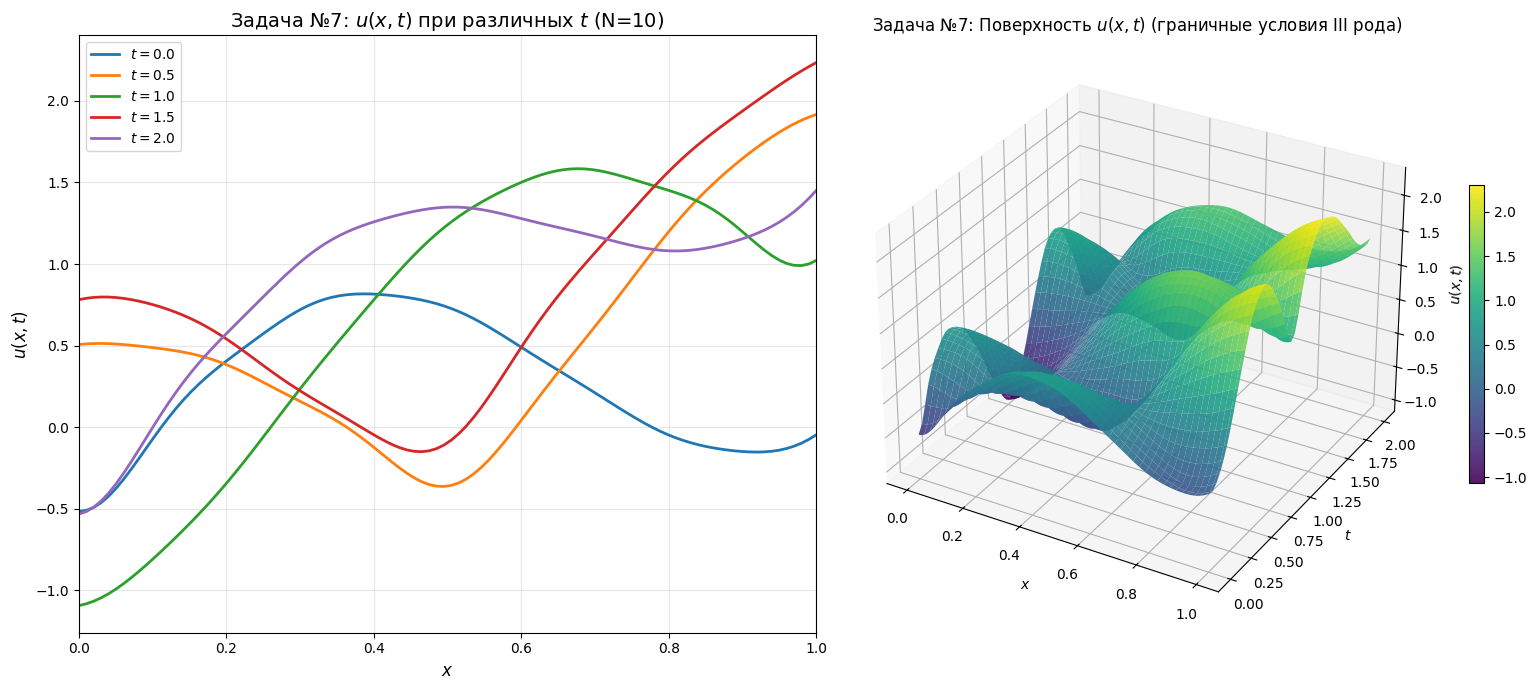

Визуализация задачи №7 с граничными условиями третьего рода


In [3]:
# Задача №7: Визуализация с численным решением (граничные условия третьего рода)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import fsolve
from scipy.integrate import quad, odeint

# Находим собственные значения (корни уравнения tan(λ) = 1/λ)
def transcendental_eq(lam):
    if abs(lam) < 1e-10:
        return 1
    return np.tan(lam) - 1/lam

# Найдем первые N собственных значений
N_TERMS = 10
eigenvalues = []
for k in range(1, N_TERMS + 1):
    # Начальное приближение для k-го корня
    initial_guess = (k - 0.5) * np.pi + 0.1
    try:
        lam_k = fsolve(transcendental_eq, initial_guess)[0]
        if lam_k > 0:  # Берем только положительные корни
            eigenvalues.append(lam_k)
    except:
        pass

print(f"Первые {len(eigenvalues)} собственных значений:")
for i, lam in enumerate(eigenvalues):
    print(f"λ_{i+1} = {lam:.6f}")

# Параметры визуализации
x = np.linspace(0, 1, 100)
t_surf = np.linspace(0, 2, 50)

# Функция s(x,t)
def s_7(x, t):
    return x * np.sin(t) + (x**2 / 3) * (2*np.cos(t) + np.exp(t) - 2*np.sin(t))

# Норма собственных функций
def norm_squared(lam):
    return 0.5 + np.sin(2*lam)/(4*lam)

# Начальные условия после приведения к однородным граничным условиям
def theta_tilde(x):
    return np.sin(3*np.pi*x/2) + x + 1 - x**2

def psi_tilde(x):
    return -np.sin(5*np.pi*x/2) - x + 1 - x**2 * (2/3)

# Вычисление коэффициентов Фурье
theta_k = []
psi_k = []

for lam in eigenvalues:
    norm2 = norm_squared(lam)
    # Коэффициенты разложения начальных условий
    theta = quad(lambda x: theta_tilde(x) * np.cos(lam*x), 0, 1)[0] / norm2
    psi = quad(lambda x: psi_tilde(x) * np.cos(lam*x), 0, 1)[0] / norm2
    theta_k.append(theta)
    psi_k.append(psi)

# Упрощенное решение для визуализации (без учета неоднородного члена для упрощения)
def u_7_analytical(x_val, t_val):
    v = sum(theta_k[i] * np.cos(eigenvalues[i] * t_val) * np.cos(eigenvalues[i] * x_val) 
            + psi_k[i]/eigenvalues[i] * np.sin(eigenvalues[i] * t_val) * np.cos(eigenvalues[i] * x_val)
            for i in range(len(eigenvalues)))
    return v + s_7(x_val, t_val)

# Визуализация
fig = plt.figure(figsize=(16, 7))

# График 1: u(x,t) при различных t
ax1 = fig.add_subplot(121)
t_values = [0, 0.5, 1.0, 1.5, 2.0]
for t in t_values:
    u = [u_7_analytical(xi, t) for xi in x]
    ax1.plot(x, u, label=f'$t = {t:.1f}$', linewidth=2)

ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$u(x,t)$', fontsize=12)
ax1.set_title(f'Задача №7: $u(x,t)$ при различных $t$ (N={len(eigenvalues)})', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])

# График 2: 3D поверхность u(x,t)
ax2 = fig.add_subplot(122, projection='3d')
X, T = np.meshgrid(x, t_surf)
U = np.array([[u_7_analytical(xi, ti) for xi in x] for ti in t_surf])

surf = ax2.plot_surface(X, T, U, cmap='viridis', alpha=0.9)
ax2.set_xlabel('$x$'); ax2.set_ylabel('$t$'); ax2.set_zlabel('$u(x,t)$')
ax2.set_title(f'Задача №7: Поверхность $u(x,t)$ (граничные условия III рода)')
fig.colorbar(surf, ax=ax2, shrink=0.5)
plt.tight_layout(); plt.show()
print("Визуализация задачи №7 с граничными условиями третьего рода")
